In [1]:
import torchvision.transforms as T
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import math

In [2]:
transform = T.Compose([
    T.Resize(224),  # ViT patch size
    T.Grayscale(num_output_channels=3),  # Convert to RGB
    T.ToTensor(),
    T.Normalize([0.5], [0.5])
])

train_ds = MNIST('data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_ds, 256, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 11.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]


In [13]:
for image,label in train_loader:
  break

In [15]:
image[0].shape

torch.Size([3, 224, 224])

In [101]:
class patchEmbedding(nn.Module):
  def __init__(self,patch_size,in_channels,embed_dim):
    super().__init__()
    self.proj = nn.Conv2d(
        in_channels = in_channels,
        out_channels = embed_dim,
        stride = patch_size,
        kernel_size = patch_size
    )
  def forward(self,x):
    ## assuming the shape of x = (batch size,channels,height,width)
    x = self.proj(x) # (batch_size,768,14,14)
    #print("proj",x.shape)
    x = x.flatten(2,-1) # (batch,768,196)
    #print("flatten",x.shape)
    x = x.transpose(1,2) # (batch_size,196,768)
    #print("transpose",x.shape)
    return x

In [102]:
class PositionalEncoding(nn.Module):
  def __init__(self,patches,embed_dim):
    super().__init__()
    ## img = (3,224,224) => (batch_size,patches,embed_dim)
    self.d_k = embed_dim
    self.patches = patches
    pe = torch.zeros(patches,self.d_k) # (197,768)
    div = torch.exp(torch.arange(0,self.d_k,2).float() * -(math.log(1000.0)/self.d_k)) # (1,384)
    ### range(0,df-2,2) => 2i
    ### -(math.log(1000.0)/self.d_k) => -log(1000.0)/d_k
    ### multiplication => (2i/d_k) * -log(100.000)
    ### exp = -1000.0^(2i/d_k) => 1/1000.o^(2i/dk)
    position = torch.arange(0,patches).float().unsqueeze(1) # (197,1)
    #print("before position")
    pe[:,0::2] = torch.sin(position*div) # only even positions are taken (197,1)*(1,384) = (197,384)
    pe[:,1::2] = torch.cos(position*div) # only the odd positions are taken(197,384)
    # (batch,197,384)
    #print("pe done ")
    pe = pe.unsqueeze(0) # adding the batch parameter
    self.register_buffer("pe",pe) # setting in the buffer to avoid the backtracking
  def forward(self,x):
    return x + (self.pe[:,:self.patches,:]).requires_grad_(False) # adding the positional vector => :self.patches are added to avoid the upscale in that dim

In [17]:
input = torch.zeros((32,197,768))
input.shape

torch.Size([32, 197, 768])

In [18]:
m = PositionalEncoding(197,768)

In [19]:
m(input).shape

torch.Size([32, 197, 768])

In [103]:
class MultiheadAttention(nn.Module):
  def __init__(self,patches,embed_dim):
    super().__init__()
    self.d_k = 64
    self.h = 12 # heads
    self.Q = nn.Linear(embed_dim,embed_dim)
    self.K = nn.Linear(embed_dim,embed_dim)
    self.V = nn.Linear(embed_dim,embed_dim)
    self.softmax = nn.Softmax(dim=-1)
    self.linear_fc = nn.Linear(embed_dim,embed_dim) # (27,27)
  def forward(self,x):
    batch,patch,embed = x.size()
    q = self.Q(x).view(batch,patch,self.h,self.d_k).transpose(1,2) ## (32,82,3,9)=>(32,3,82,9)
    k = self.K(x).view(batch,patch,self.h,self.d_k).transpose(1,2) ## (32,82,27)
    v = self.V(x).view(batch,patch,self.h,self.d_k).transpose(1,2) ## (32,82,27)
    #print(q.shape)
    k_t = k.transpose(-2,-1) ## (32,27,82) => why -2,-1 := like replace the 82 with 27
    attention = self.softmax((q @ k_t)/math.sqrt(self.d_k)) @ v ## (32,3,82,9)
    #print(attention.shape)
    out = attention.transpose(1,2).contiguous().view(batch,patch,embed) ## (32,82.27)
    #print(out.shape)
    return self.linear_fc(out) # (32,82,27)

In [104]:
class LayerNorm(nn.Module):
  def __init__(self):
    super().__init__()
    self.eps = 0.01
    self.alpha = nn.Parameter(torch.ones(1))
    self.beta = nn.Parameter(torch.ones(1))
    pass
  def forward(self,x):
    mean = x.mean(dim=-1,keepdim=True)
    std = x.std(dim=-1,keepdim=True)
    return (self.alpha * ((x - mean)/(std+self.eps))) + self.beta

In [105]:
class FeedForwardlayer(nn.Module):
  def __init__(self,patches,embed_dim):
    super().__init__()
    self.dim = 348
    self.fc_1 = nn.Linear(embed_dim,self.dim)
    self.fc_2 = nn.Linear(self.dim,embed_dim)
    self.relu = nn.ReLU()
  def forward(self,x):
    return self.fc_2(self.relu(self.fc_1(x)))

In [106]:
class ResidualBlock(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm = LayerNorm()
  def forward(self,X,sublayer):
    #print("in residual ")
    return X + sublayer(self.layer_norm(X)) # ada and norm
    ## here the sublayer is normed first then add

In [107]:
class EncoderBlock(nn.Module):
  def __init__(self,attention:MultiheadAttention,fnn:FeedForwardlayer,patches,embed_dim):
    super().__init__()
    self.attention = attention
    self.fnn = fnn
    self.patches = patches
    self.embed_dim = embed_dim
    self.residual = nn.ModuleList([ResidualBlock() for _ in range(2)]) # we want and 2 residual layer connected
  def forward(self,X):
    X = self.residual[0](X,lambda x:self.attention(X)) ## here the attention is second layer (sublayer) and the X is the input which is going to add
    X = self.residual[1](X,lambda x:self.fnn(X))
    return X

In [108]:
class ViTClassifier(nn.Module):
    def __init__(self,embeded_dim,num_classes):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(embeded_dim, 2048),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        return self.head(x)

In [109]:
patches = 197
embed_dim =  768
num_classes = 10
patch_size = 16
patch_embedding = patchEmbedding(patch_size,3,embed_dim)
positional = PositionalEncoding(patches,embed_dim)
attention = MultiheadAttention(patches,embed_dim)
residual = ResidualBlock()
fnn = FeedForwardlayer(patches,embed_dim)
encoder = EncoderBlock(attention,fnn,patches,embed_dim)
classifier = ViTClassifier(embed_dim,num_classes)

In [110]:
class ViT(nn.Module):
    def __init__(self, patches=197,patch_size=16, embed_dim=768, num_classes=10):
        super().__init__()
        self.patch_embedding = patchEmbedding(patch_size, 3, embed_dim)
        self.positional = PositionalEncoding(patches, embed_dim)
        self.encoder = encoder
        self.classifier = classifier
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

    def forward(self, x):
        x = self.patch_embedding(x)
        #print(x.shape)
        #print("cls",cls_token.shape)
        #print(x.shape)
        x = torch.cat([self.cls_token.expand(x.size(0), -1, -1), x], dim=1)
        #print(x.shape)
        x = self.positional(x)
        x = self.encoder(x)
        cls_features = x[:, 0, :]  # Take CLS token
        return self.classifier(cls_features)


In [111]:
model = ViT(patches,patch_size,embed_dim,num_classes)

In [112]:
model

ViT(
  (patch_embedding): patchEmbedding(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (positional): PositionalEncoding()
  (encoder): EncoderBlock(
    (attention): MultiheadAttention(
      (Q): Linear(in_features=768, out_features=768, bias=True)
      (K): Linear(in_features=768, out_features=768, bias=True)
      (V): Linear(in_features=768, out_features=768, bias=True)
      (softmax): Softmax(dim=-1)
      (linear_fc): Linear(in_features=768, out_features=768, bias=True)
    )
    (fnn): FeedForwardlayer(
      (fc_1): Linear(in_features=768, out_features=348, bias=True)
      (fc_2): Linear(in_features=348, out_features=768, bias=True)
      (relu): ReLU()
    )
    (residual): ModuleList(
      (0-1): 2 x ResidualBlock(
        (layer_norm): LayerNorm()
      )
    )
  )
  (classifier): ViTClassifier(
    (head): Sequential(
      (0): Linear(in_features=768, out_features=2048, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.5, 

In [113]:
for batch,image in train_loader:
  break

In [114]:
model(batch)

tensor([[ 0.2766, -0.0988,  0.3633,  ...,  0.6749, -0.1873,  0.0141],
        [ 0.0430, -0.5549,  0.2079,  ...,  0.2007, -0.4938, -0.0503],
        [ 0.3413, -0.0899, -0.1862,  ...,  0.1785, -0.6326, -0.2805],
        ...,
        [ 0.2095, -0.0970,  0.4209,  ...,  0.4637, -0.2354, -0.4244],
        [ 0.4629, -0.2926,  0.4508,  ...,  0.1299, -0.0392, -0.6630],
        [ 0.4119,  0.1309,  0.7751,  ..., -0.0885, -0.7520, -0.1773]],
       grad_fn=<AddmmBackward0>)

In [115]:
import torch.optim as optim
from torch.nn import CrossEntropyLoss

In [116]:
optimizer = optim.Adam(model.parameters(),lr=0.01)
loss = CrossEntropyLoss()

In [117]:
train_loader.__len__()

235

In [118]:
from tqdm.notebook import tqdm, trange

In [119]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ViT(patches, patch_size, embed_dim, num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=3e-4)  # Lower LR for ViT
criterion = nn.CrossEntropyLoss()  # Use nn directly
epochs = 10

for epoch in trange(epochs, desc="Training Progress"):
    model.train()
    total_loss = 0
    for batch_idx, (image, label) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch}", leave=False)):
        image, label = image.to(device), label.to(device)

        optimizer.zero_grad()
        pred = model(image)
        loss = criterion(pred, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch}: Avg Loss = {avg_loss:.4f}")

Training Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 0:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 0: Avg Loss = 0.5821


Epoch 1:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 1: Avg Loss = 0.1553


...

Epoch 7: Avg Loss = 0.0678


Epoch 8:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 8: Avg Loss = 0.0651


Epoch 9:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 9: Avg Loss = 0.0643


In [120]:
for image,label in train_loader:
  break

In [126]:
model.eval()
with torch.no_grad():
    image = image.to(device)
    pred = model(image)
    probabilities = torch.softmax(pred, dim=1)  # Apply softmax across classes
    probabilities = probabilities.cpu().numpy()  # Convert to numpy for list

# Get predictions for all images in batch (num_classes=10)
print("Predictions for all images (softmax probabilities):")
for i, probs in enumerate(probabilities):
    predicted_class = torch.argmax(pred[i]).item()
    print(f"Image {i}: Predicted class {predicted_class}")


Predictions for all images (softmax probabilities):
Image 0: Predicted class 7
Image 1: Predicted class 7
Image 2: Predicted class 4
Image 3: Predicted class 4
Image 4: Predicted class 2
Image 5: Predicted class 0
Image 6: Predicted class 0
Image 7: Predicted class 0
Image 8: Predicted class 1
Image 9: Predicted class 8
Image 10: Predicted class 3
Image 11: Predicted class 9
Image 12: Predicted class 4
Image 13: Predicted class 3
Image 14: Predicted class 4
Image 15: Predicted class 6
Image 16: Predicted class 2
Image 17: Predicted class 6
Image 18: Predicted class 0
Image 19: Predicted class 3
Image 20: Predicted class 7
Image 21: Predicted class 1
Image 22: Predicted class 0
Image 23: Predicted class 0
Image 24: Predicted class 0
Image 25: Predicted class 6
Image 26: Predicted class 1
Image 27: Predicted class 0
Image 28: Predicted class 6
Image 29: Predicted class 9
Image 30: Predicted class 3
Image 31: Predicted class 9
Image 32: Predicted class 2
Image 33: Predicted class 5
Image 

In [127]:
image[0].shape

torch.Size([3, 224, 224])

In [128]:
import matplotlib.pyplot as plt

class: 3


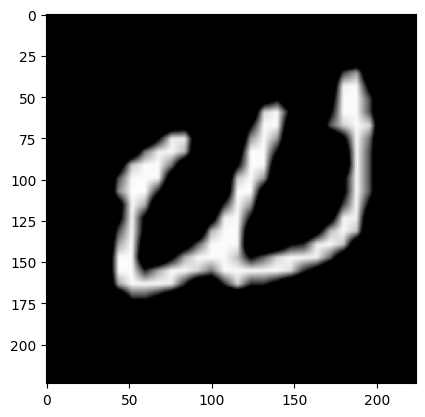

In [136]:
number = 10
predicted_class = torch.argmax(pred[number]).item()
print("class:",predicted_class)
plt.imshow(image[number].cpu().numpy().transpose(2,1,0))
plt.show()

# VIT trained